### Import Library

In [29]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

### Load Dataset + Splitting data

In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(28, 28),
    color_mode="grayscale",
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(28, 28),
    color_mode="grayscale",
    batch_size=32,
    label_mode="categorical"
)


Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.


In [22]:
# Cek Label
print(train_ds.class_names)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


### Normalisasi Data

In [23]:
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
test_ds  = test_ds.map(lambda x, y: (x / 255.0, y))

### Pemodelan

In [24]:
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

In [25]:
# Compile Model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Training Data

In [32]:
history = model.fit(
    train_ds,
    validation_data=test_ds, 
    epochs=50
)

Epoch 1/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.5035 - loss: 1.5596 - val_accuracy: 0.4544 - val_loss: 1.6744
Epoch 2/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5096 - loss: 1.5431 - val_accuracy: 0.4904 - val_loss: 1.6104
Epoch 3/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5211 - loss: 1.5192 - val_accuracy: 0.4892 - val_loss: 1.6148
Epoch 4/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5217 - loss: 1.5083 - val_accuracy: 0.4744 - val_loss: 1.6365
Epoch 5/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5219 - loss: 1.5031 - val_accuracy: 0.4973 - val_loss: 1.5789
Epoch 6/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5282 - loss: 1.4806 - val_accuracy: 0.4774 - val_loss: 1.6177
Epoch 7/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.5251 - loss: 1.4822 - val_accuracy: 0.4788 - val_loss: 1.5907
Epoch 8/50
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5357 - loss: 1.4599 - val_

### Evaluasi

In [33]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6029 - loss: 1.2735
Test Loss: 1.2735369205474854
Test Accuracy: 0.6028763651847839


### Visualisasi Hasil Accuracy & Loss

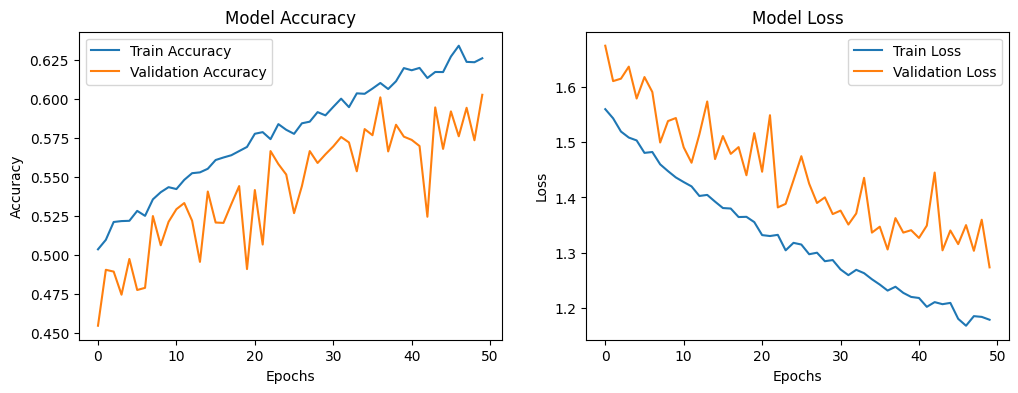

In [34]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()